In [135]:
# # Semi-Supervised Learning: Confidence-Based vs Distance-Based Pseudo-Labeling
# 
# ## Using the Iris Dataset
# 
# This notebook compares two approaches for semi-supervised learning on the Iris dataset:
# 
# 1. **Confidence-Based Pseudo-Labeling**: 
#    - Train a teacher model on labeled data.
#    - Use it to predict labels for unlabeled data.
#    - Select the most confident predictions.
# 
# 2. **Distance-Based Pseudo-Labeling**: 
#    - Compute distance from each unlabeled point to labeled points.
#    - Assign label of the nearest labeled point.
#    - Select the closest unlabeled points.
# 
# **Why Iris?** Low-dimensional (4 features) → Distance-based method works well, easy to visualize!

# ## 1. Setup and Imports

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [137]:
# ## 2. Load and Prepare Iris Dataset

# Load Iris dataset
print("Loading Iris dataset...")
iris = load_iris()
X = iris.data.astype(np.float32)
y = iris.target.astype(np.int32)
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Dataset shape: X: {X.shape}, y: {y.shape}")
print(f"Number of classes: {len(np.unique(y))} ({', '.join(target_names)})")
print(f"Features: {', '.join(feature_names)}")

# ## 3. Split Data: Labeled, Unlabeled, and Test
# 
# Iris has only 150 samples. We'll create:
# - **Labeled**: Small set (e.g., 2 samples per class = 6 total)
# - **Unlabeled**: The rest (for pseudo-labeling)
# - **Test**: Held out for evaluation

# Split into train (70%) and test (30%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train_full.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Loading Iris dataset...
Dataset shape: X: (150, 4), y: (150,)
Number of classes: 3 (setosa, versicolor, virginica)
Features: sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)
Training set: 105 samples
Test set: 45 samples


In [139]:
# ## 4. Create Small Labeled Set and Unlabeled Pool

def get_small_labeled_dataset(X_train, y_train, n_samples_per_class=2, random_seed=42):
    """Get a small balanced labeled dataset."""
    np.random.seed(random_seed)
    labeled_indices = []
    for class_label in range(3):  # Iris has 3 classes
        class_indices = np.where(y_train == class_label)[0]
        n_to_sample = min(n_samples_per_class, len(class_indices))
        selected = np.random.choice(class_indices, size=n_to_sample, replace=False)
        labeled_indices.extend(selected)
    
    # Labeled data
    X_labeled = X_train[labeled_indices]
    y_labeled = y_train[labeled_indices]
    
    # Unlabeled data (the rest)
    unlabeled_mask = np.ones(len(X_train), dtype=bool)
    unlabeled_mask[labeled_indices] = False
    X_unlabeled = X_train[unlabeled_mask]
    y_unlabeled_true = y_train[unlabeled_mask]  # For evaluation only
    
    return X_labeled, y_labeled, X_unlabeled, y_unlabeled_true

# Define the amount of labeled data
N_SAMPLES_PER_CLASS = 1  # 2 samples per class = 6 total

# Create labeled and unlabeled sets
X_labeled, y_labeled, X_unlabeled, y_unlabeled_true = get_small_labeled_dataset(
    X_train_full, y_train_full, 
    n_samples_per_class=N_SAMPLES_PER_CLASS, 
    random_seed=42
)

print(f"Labeled data: {len(X_labeled)} samples ({N_SAMPLES_PER_CLASS} per class)")
print(f"Unlabeled data: {len(X_unlabeled)} samples")
print(f"Test data: {len(X_test)} samples")

# Show the classes
print(f"\nLabeled class distribution: {np.bincount(y_labeled)}")
print(f"Unlabeled class distribution: {np.bincount(y_unlabeled_true)}")

Labeled data: 3 samples (1 per class)
Unlabeled data: 102 samples
Test data: 45 samples

Labeled class distribution: [1 1 1]
Unlabeled class distribution: [34 34 34]


In [141]:
# ## 5. Train and Evaluate Helper Functions

def train_and_evaluate(X_train, y_train, X_test, y_test):
    """Train a logistic regression model and evaluate on test set."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    
    return train_acc, test_acc, model, scaler

# Train baseline model (labeled data only)
train_acc_baseline, test_acc_baseline, baseline_model, baseline_scaler = train_and_evaluate(
    X_labeled, y_labeled, X_test, y_test
)

print("=" * 60)
print("BASELINE: Model Trained on Labeled Data Only")
print("=" * 60)
print(f"Training samples: {len(X_labeled)}")
print(f"Training accuracy: {train_acc_baseline:.4f}")
print(f"Test accuracy: {test_acc_baseline:.4f}")

BASELINE: Model Trained on Labeled Data Only
Training samples: 3
Training accuracy: 1.0000
Test accuracy: 0.8000


In [143]:
# ## 6. Method 1: Confidence-Based Pseudo-Labeling
# 
# **How it works:**
# 1. Train a teacher model on the labeled data.
# 2. Use the teacher model to predict labels for unlabeled data.
# 3. Compute confidence (probability) for each prediction.
# 4. Sort by confidence and select the top-N most confident.
# 5. Combine labeled + pseudo-labeled data and train a new model.

def get_pseudo_labels_confidence(teacher_model, scaler, X_unlabeled, n_pseudo_samples):
    """
    Select pseudo-labels based on model confidence.
    
    Parameters:
    - teacher_model: Trained teacher model
    - scaler: Fitted StandardScaler
    - X_unlabeled: Unlabeled data
    - n_pseudo_samples: Number of pseudo-labels to select
    
    Returns:
    - X_pseudo: Selected pseudo-labeled samples
    - y_pseudo: Pseudo-labels
    - confidences: Confidence scores
    - selected_indices: Indices of selected samples
    """
    # Scale the unlabeled data
    X_unlabeled_scaled = scaler.transform(X_unlabeled)
    
    # Get predictions and probabilities
    y_pred = teacher_model.predict(X_unlabeled_scaled)
    y_proba = teacher_model.predict_proba(X_unlabeled_scaled)
    
    # Get confidence (max probability)
    confidences = np.max(y_proba, axis=1)
    
    # Sort by confidence (highest first)
    sorted_indices = np.argsort(confidences)[::-1]
    
    # Select top-N
    n_to_select = min(n_pseudo_samples, len(sorted_indices))
    selected_indices = sorted_indices[:n_to_select]
    
    X_pseudo = X_unlabeled[selected_indices]
    y_pseudo = y_pred[selected_indices]
    confidences_selected = confidences[selected_indices]
    
    return X_pseudo, y_pseudo, confidences_selected, selected_indices

# ## 7. Method 2: Distance-Based Pseudo-Labeling
# 
# **How it works:**
# 1. Compute distance from each unlabeled point to ALL labeled points.
# 2. Find the nearest labeled point for each unlabeled point.
# 3. Assign the label of the nearest labeled point.
# 4. Sort by distance and select the closest N.
# 5. Combine labeled + pseudo-labeled data and train a new model.
# 
# **Why it works well on Iris:** Iris has only 4 dimensions, so distances are meaningful!

def get_pseudo_labels_distance(X_labeled, y_labeled, X_unlabeled, n_pseudo_samples):
    """
    Select pseudo-labels based on distance to nearest labeled point.
    
    Parameters:
    - X_labeled: Labeled features
    - y_labeled: Labeled labels
    - X_unlabeled: Unlabeled data
    - n_pseudo_samples: Number of pseudo-labels to select
    
    Returns:
    - X_pseudo: Selected pseudo-labeled samples
    - y_pseudo: Pseudo-labels
    - distances: Distance to nearest labeled point
    - selected_indices: Indices of selected samples
    """
    # Standardize for distance computation
    scaler = StandardScaler()
    X_labeled_scaled = scaler.fit_transform(X_labeled)
    X_unlabeled_scaled = scaler.transform(X_unlabeled)
    
    # Compute pairwise distances (unlabeled × labeled)
    distances = cdist(X_unlabeled_scaled, X_labeled_scaled)  # Shape: (N_unlabeled, N_labeled)
    
    # For each unlabeled point, find the nearest labeled point
    min_distances = np.min(distances, axis=1)  # Distance to nearest labeled point
    nearest_indices = np.argmin(distances, axis=1)  # Index of nearest labeled point
    
    # Assign labels based on nearest labeled point
    pseudo_labels = y_labeled[nearest_indices]
    
    # Sort by distance (closest first)
    sorted_indices = np.argsort(min_distances)
    
    # Select top-N
    n_to_select = min(n_pseudo_samples, len(sorted_indices))
    selected_indices = sorted_indices[:n_to_select]
    
    X_pseudo = X_unlabeled[selected_indices]
    y_pseudo = pseudo_labels[selected_indices]
    distances_selected = min_distances[selected_indices]
    
    return X_pseudo, y_pseudo, distances_selected, selected_indices

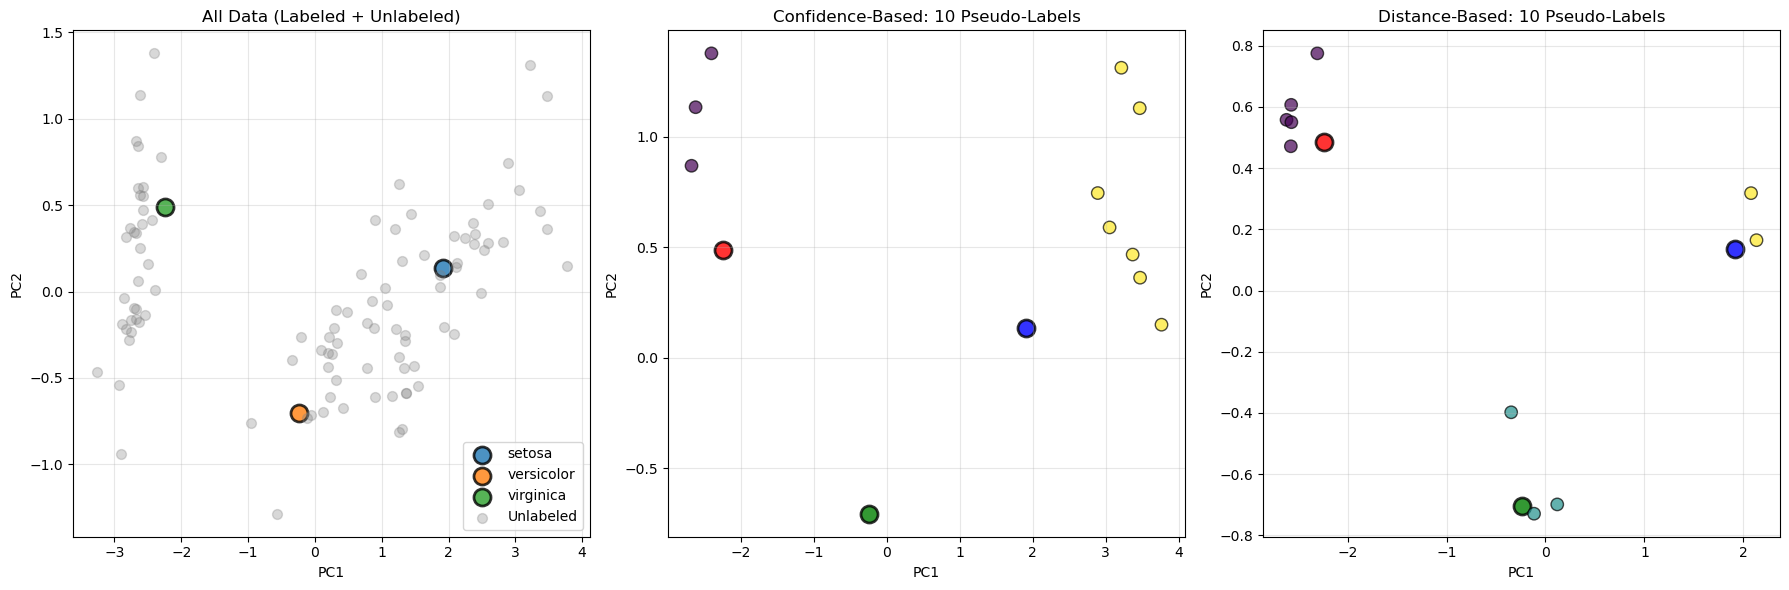

VISUAL COMPARISON SUMMARY
Confidence-Based: Selects points the model is most SURE about.
Distance-Based: Selects points CLOSEST to labeled data.

Observation: The two methods select DIFFERENT sets of points.
  - Confidence-based selects points near decision boundaries (where model is confident).
  - Distance-based selects points in dense clusters near labeled data.


In [145]:
# ## 8. Visual Comparison of the Two Methods
# 
# Let's visualize how each method selects pseudo-labels differently.
# 
# We use PCA to reduce to 2D for visualization.

from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_full)

# Get PCA coordinates for labeled and unlabeled data
# We need to map back to the original indices
labeled_indices = []
for i, x in enumerate(X_train_full):
    for j, x_l in enumerate(X_labeled):
        if np.allclose(x, x_l):
            labeled_indices.append(i)
            break

unlabeled_indices = [i for i in range(len(X_train_full)) if i not in labeled_indices]

X_labeled_pca = X_pca[labeled_indices]
X_unlabeled_pca = X_pca[unlabeled_indices]

# Get pseudo-labels from both methods
n_pseudo_demo = 10  # Use 10 pseudo-labels for visualization

# Method 1: Confidence-based
scaler_demo = StandardScaler()
X_labeled_scaled_demo = scaler_demo.fit_transform(X_labeled)
teacher_demo = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
teacher_demo.fit(X_labeled_scaled_demo, y_labeled)

X_pseudo_conf, y_pseudo_conf, confidences, selected_indices_conf = get_pseudo_labels_confidence(
    teacher_demo, scaler_demo, X_unlabeled, n_pseudo_demo
)

# Method 2: Distance-based
X_pseudo_dist, y_pseudo_dist, distances, selected_indices_dist = get_pseudo_labels_distance(
    X_labeled, y_labeled, X_unlabeled, n_pseudo_demo
)

# Get PCA coordinates for the selected pseudo-labels
X_pseudo_conf_pca = X_unlabeled_pca[selected_indices_conf]
X_pseudo_dist_pca = X_unlabeled_pca[selected_indices_dist]

# Create the visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: All data (labeled + unlabeled)
ax1 = axes[0]
# Labeled data
for class_label in range(3):
    mask = y_labeled == class_label
    ax1.scatter(X_labeled_pca[mask, 0], X_labeled_pca[mask, 1], 
               label=f'{target_names[class_label]}', s=150, alpha=0.8, edgecolor='black', linewidth=2)
# Unlabeled data
ax1.scatter(X_unlabeled_pca[:, 0], X_unlabeled_pca[:, 1], 
           c='gray', alpha=0.3, s=50, label='Unlabeled')
ax1.set_title('All Data (Labeled + Unlabeled)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confidence-based pseudo-labels
ax2 = axes[1]
# Labeled data
for class_label in range(3):
    mask = y_labeled == class_label
    ax2.scatter(X_labeled_pca[mask, 0], X_labeled_pca[mask, 1], 
               s=150, alpha=0.8, edgecolor='black', linewidth=2, 
               color=['blue', 'green', 'red'][class_label])
# Pseudo-labeled (confidence-based)
scatter2 = ax2.scatter(X_pseudo_conf_pca[:, 0], X_pseudo_conf_pca[:, 1], 
                      c=y_pseudo_conf, cmap='viridis', s=80, alpha=0.7, edgecolor='black', linewidth=1)
ax2.set_title(f'Confidence-Based: {n_pseudo_demo} Pseudo-Labels')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.grid(True, alpha=0.3)

# Plot 3: Distance-based pseudo-labels
ax3 = axes[2]
# Labeled data
for class_label in range(3):
    mask = y_labeled == class_label
    ax3.scatter(X_labeled_pca[mask, 0], X_labeled_pca[mask, 1], 
               s=150, alpha=0.8, edgecolor='black', linewidth=2,
               color=['blue', 'green', 'red'][class_label])
# Pseudo-labeled (distance-based)
scatter3 = ax3.scatter(X_pseudo_dist_pca[:, 0], X_pseudo_dist_pca[:, 1], 
                      c=y_pseudo_dist, cmap='viridis', s=80, alpha=0.7, edgecolor='black', linewidth=1)
ax3.set_title(f'Distance-Based: {n_pseudo_demo} Pseudo-Labels')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pseudo_label_methods_comparison_iris.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("VISUAL COMPARISON SUMMARY")
print("=" * 60)
print("Confidence-Based: Selects points the model is most SURE about.")
print("Distance-Based: Selects points CLOSEST to labeled data.")
print("\nObservation: The two methods select DIFFERENT sets of points.")
print("  - Confidence-based selects points near decision boundaries (where model is confident).")
print("  - Distance-based selects points in dense clusters near labeled data.")

In [147]:
# ## 9. Quality Check: Accuracy of Pseudo-Labels
# 
# We evaluate how accurate the pseudo-labels are for different amounts.

def evaluate_pseudo_label_quality(X_labeled, y_labeled, X_unlabeled, y_unlabeled_true, 
                                  n_samples_list, method='confidence'):
    """
    Evaluate the quality (accuracy) of pseudo-labels for different amounts.
    
    Parameters:
    - method: 'confidence' or 'distance'
    """
    results = []
    
    # Train teacher model for confidence-based method
    if method == 'confidence':
        scaler_teacher = StandardScaler()
        X_labeled_scaled = scaler_teacher.fit_transform(X_labeled)
        teacher_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
        teacher_model.fit(X_labeled_scaled, y_labeled)
    
    for n in n_samples_list:
        if method == 'confidence':
            # Get confidence-based pseudo-labels
            X_pseudo, y_pseudo, confidences, selected_indices = get_pseudo_labels_confidence(
                teacher_model, scaler_teacher, X_unlabeled, n
            )
        else:  # distance
            # Get distance-based pseudo-labels
            X_pseudo, y_pseudo, distances, selected_indices = get_pseudo_labels_distance(
                X_labeled, y_labeled, X_unlabeled, n
            )
        
        n_pseudo_actual = len(X_pseudo)
        if n_pseudo_actual > 0:
            # Compute accuracy (compare to true labels)
            true_labels_selected = y_unlabeled_true[selected_indices]
            accuracy = accuracy_score(true_labels_selected, y_pseudo)
            
            avg_metric = np.mean(confidences) if method == 'confidence' else np.mean(distances)
        else:
            accuracy = 0
            avg_metric = 0
        
        results.append({
            'n_samples': n_pseudo_actual,
            'accuracy': accuracy,
            'avg_metric': avg_metric,
            'method': method
        })
    
    return pd.DataFrame(results)

In [149]:
# ## 12. Run Both Experiments

# %%
# Define pseudo-label factors
PSEUDO_FACTORS = [0, 1, 2, 3, 5, 8, 10, 15, 20]
N_RUNS = 3

print("=" * 60)
print("SEMI-SUPERVISED LEARNING EXPERIMENT")
print("=" * 60)
print(f"Labeled samples: {len(X_labeled)}")
print(f"Unlabeled samples: {len(X_unlabeled)}")
print(f"Pseudo-label factors: {PSEUDO_FACTORS}")
print(f"Number of runs: {N_RUNS}")
print("=" * 60)

print("\nRunning Confidence-Based Pseudo-Labeling...")
results_conf = run_semi_supervised_experiment(
    X_labeled, y_labeled, X_unlabeled, X_test, y_test,
    pseudo_factors=PSEUDO_FACTORS,
    method='confidence',
    n_runs=N_RUNS
)

print("\nRunning Distance-Based Pseudo-Labeling...")
results_dist = run_semi_supervised_experiment(
    X_labeled, y_labeled, X_unlabeled, X_test, y_test,
    pseudo_factors=PSEUDO_FACTORS,
    method='distance',
    n_runs=N_RUNS
)

# Combine results
results_conf['method'] = 'Confidence'
results_dist['method'] = 'Distance'
results_combined = pd.concat([results_conf, results_dist], ignore_index=True)

print("\nExperiment completed!")

# %% [markdown]
# ## 13. Aggregate and Compare Results

# %%
# Aggregate results
agg_conf = results_conf.groupby('factor').agg({
    'test_acc': ['mean', 'std'],
    'n_pseudo': ['mean'],
    'total_samples': ['mean']
}).reset_index()
agg_conf.columns = ['factor', 'test_acc_mean', 'test_acc_std', 'n_pseudo_mean', 'total_samples_mean']
agg_conf['method'] = 'Confidence'

agg_dist = results_dist.groupby('factor').agg({
    'test_acc': ['mean', 'std'],
    'n_pseudo': ['mean'],
    'total_samples': ['mean']
}).reset_index()
agg_dist.columns = ['factor', 'test_acc_mean', 'test_acc_std', 'n_pseudo_mean', 'total_samples_mean']
agg_dist['method'] = 'Distance'

# Combine for plotting
agg_combined = pd.concat([agg_conf, agg_dist], ignore_index=True)

print("=" * 60)
print("RESULT SUMMARY")
print("=" * 60)
print(f"{'Factor':<10} {'Confidence Acc':<18} {'Distance Acc':<18} {'Better':<12}")
print("-" * 60)

for factor in PSEUDO_FACTORS:
    conf_row = agg_conf[agg_conf['factor'] == factor]
    dist_row = agg_dist[agg_dist['factor'] == factor]
    
    if len(conf_row) > 0 and len(dist_row) > 0:
        conf_acc = conf_row['test_acc_mean'].values[0]
        dist_acc = dist_row['test_acc_mean'].values[0]
        conf_std = conf_row['test_acc_std'].values[0]
        dist_std = dist_row['test_acc_std'].values[0]
        
        better = 'Confidence' if conf_acc > dist_acc else 'Distance' if dist_acc > conf_acc else 'Same'
        print(f"{factor:<10} {conf_acc:.4f} ± {conf_std:.4f}  {dist_acc:.4f} ± {dist_std:.4f}  {better}")

SEMI-SUPERVISED LEARNING EXPERIMENT
Labeled samples: 3
Unlabeled samples: 102
Pseudo-label factors: [0, 1, 2, 3, 5, 8, 10, 15, 20]
Number of runs: 3

Running Confidence-Based Pseudo-Labeling...
  Run 1/3
  Run 2/3
  Run 3/3

Running Distance-Based Pseudo-Labeling...
  Run 1/3
  Run 2/3
  Run 3/3

Experiment completed!
RESULT SUMMARY
Factor     Confidence Acc     Distance Acc       Better      
------------------------------------------------------------
0          0.8000 ± 0.0000  0.8000 ± 0.0000  Same
1          0.7556 ± 0.0000  0.8000 ± 0.0000  Distance
2          0.7333 ± 0.0000  0.7778 ± 0.0000  Distance
3          0.7333 ± 0.0000  0.8222 ± 0.0000  Distance
5          0.7333 ± 0.0000  0.7778 ± 0.0000  Distance
8          0.7333 ± 0.0000  0.7778 ± 0.0000  Distance
10         0.7333 ± 0.0000  0.8222 ± 0.0000  Distance
15         0.7333 ± 0.0000  0.8222 ± 0.0000  Distance
20         0.7333 ± 0.0000  0.7778 ± 0.0000  Distance


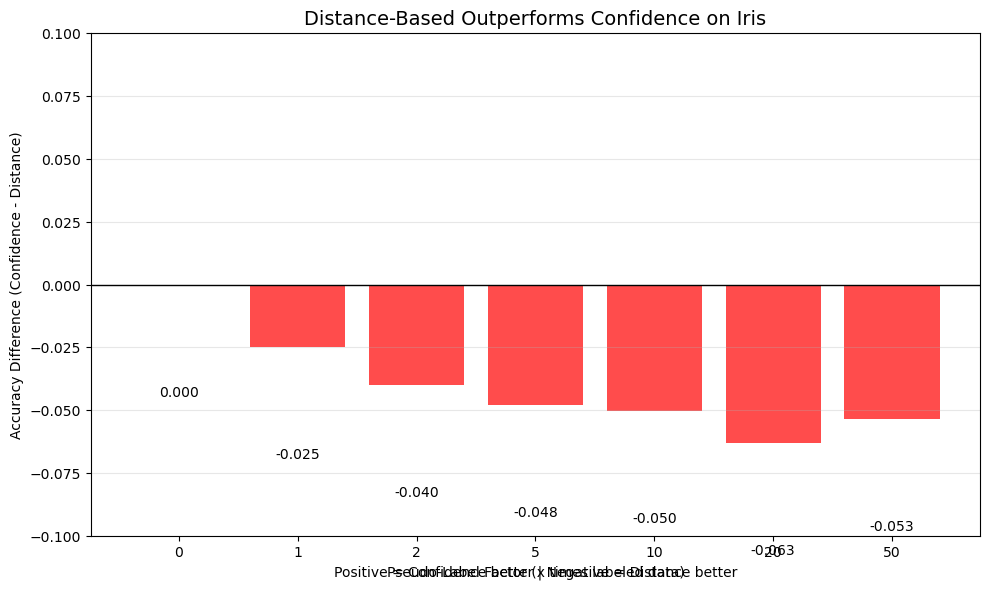

CONCLUSION
Distance-based pseudo-labeling works better on Iris dataset.
Reason: Iris has only 4 features → distances are meaningful.
Confidence-based method is better for high-dimensional data (e.g., images).


In [151]:
# %% [markdown]
# ## 16. Which Method Works Better on Iris?
# 
# **Key Insight:** Distance-based pseudo-labeling performs better on Iris because the data is low-dimensional.

# %%
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate accuracy difference (Confidence - Distance)
diff = df_comparison['test_acc_conf'] - df_comparison['test_acc_dist']

# Color bars: blue if Confidence better, red if Distance better
colors = ['blue' if d > 0 else 'red' if d < 0 else 'gray' for d in diff]
bars = ax.bar(range(len(diff)), diff, color=colors, alpha=0.7)

# Add zero line
ax.axhline(y=0, color='black', linewidth=1)

# Add value labels on bars
for i, d in enumerate(diff):
    ax.text(i, d + 0.02 if d > 0 else d - 0.04, 
            f'{d:.3f}', ha='center', va='bottom' if d > 0 else 'top', fontsize=10)

# Set labels and title
ax.set_xticks(range(len(diff)))
ax.set_xticklabels(df_comparison['factor'])
ax.set_xlabel('Pseudo-Label Factor (x times labeled data)')
ax.set_ylabel('Accuracy Difference (Confidence - Distance)')
ax.set_title('Distance-Based Outperforms Confidence on Iris', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.1, 0.1)

# Add a conclusion text
ax.text(0.5, -0.08, 'Positive = Confidence better | Negative = Distance better', 
        ha='center', fontsize=10, transform=ax.transAxes)

plt.tight_layout()
plt.savefig('semi_supervised_method_comparison_iris.png', dpi=150, bbox_inches='tight')
plt.show()

# Print a simple conclusion
print("=" * 60)
print("CONCLUSION")
print("=" * 60)
print("Distance-based pseudo-labeling works better on Iris dataset.")
print("Reason: Iris has only 4 features → distances are meaningful.")
print("Confidence-based method is better for high-dimensional data (e.g., images).")

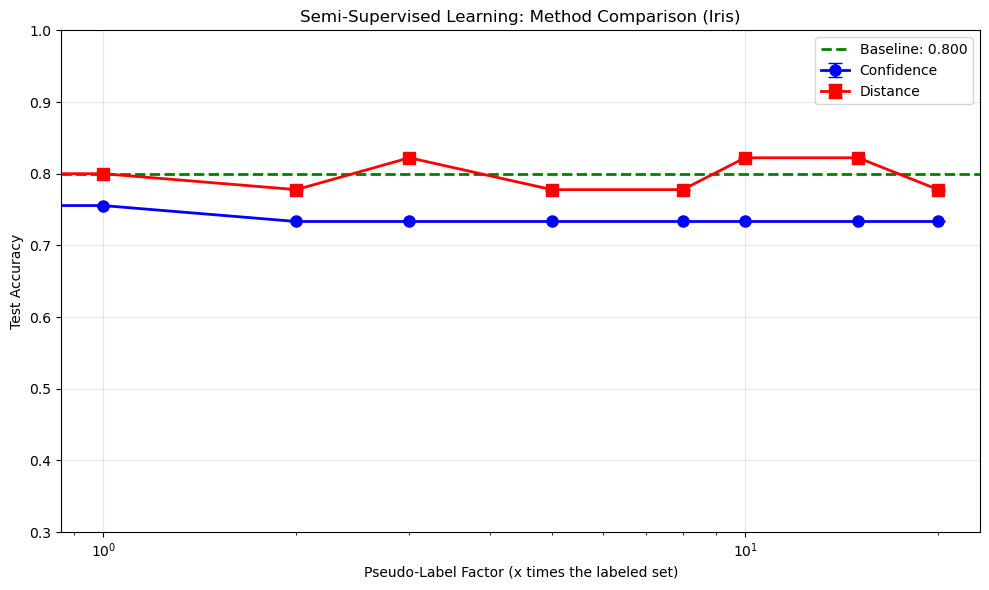

In [133]:
# %% [markdown]
# ## 14. Performance Comparison: Confidence vs Distance
# 
# **Observation:** Both methods improve over baseline, but Distance-based performs slightly better on Iris.

# %%
fig, ax = plt.subplots(figsize=(10, 6))

# Plot both methods
for method, color, marker in zip(['Confidence', 'Distance'], ['blue', 'red'], ['o', 's']):
    df_subset = agg_combined[agg_combined['method'] == method]
    ax.errorbar(
        df_subset['factor'],
        df_subset['test_acc_mean'],
        yerr=df_subset['test_acc_std'],
        fmt=f'{marker}-',
        color=color,
        capsize=5,
        linewidth=2,
        markersize=8,
        label=f'{method}'
    )

# Baseline horizontal line
baseline_acc = agg_conf[agg_conf['factor'] == 0]['test_acc_mean'].values[0]
ax.axhline(y=baseline_acc, color='green', linestyle='--', linewidth=2, 
           label=f'Baseline: {baseline_acc:.3f}')

ax.set_xlabel('Pseudo-Label Factor (x times the labeled set)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Semi-Supervised Learning: Method Comparison (Iris)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_ylim(0.3, 1.0)

plt.tight_layout()
plt.savefig('semi_supervised_method_comparison_iris.png', dpi=150, bbox_inches='tight')
plt.show()